In [1]:
import pandas as pd 

df = pd.read_csv('WCR_latest_TWS_cleaned_V2.csv')
df.head()

,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
0,2024-12-15 10:20:59,ARNETHA,101/102,Reverse,"[0.0, 1.7, 4.9, 4.1, 3.3, 2.7, 2.3, 2.1, 1.9, ...","[0.0, 52.5, 79.5, 94.5, 100.5, 105.0, 106.5, 1...","[0.0, 3.9, 5.2, 4.1, 3.2, 2.6, 2.3, 2.1, 2.0, ...","[0.0, 103.5, 103.5, 103.5, 100.5, 97.5, 94.5, ...",TWS,TWS,20,20
1,2024-12-15 10:21:08,ARNETHA,101/102,Normal,"[0.0, 5.2, 4.6, 3.7, 3.0, 2.6, 2.2, 2.1, 2.0, ...","[0.0, 85.5, 90.0, 97.5, 103.5, 106.5, 109.5, 1...","[0.0, 1.5, 4.7, 3.9, 3.2, 2.7, 2.4, 2.1, 2.0, ...","[0.0, 12.0, 45.0, 73.5, 90.0, 99.0, 105.0, 108...",TWS,TWS,20,20
2,2024-12-16 07:28:55,ARNETHA,101/102,Normal,"[0.0, 5.2, 4.5, 3.6, 3.0, 2.6, 2.2, 2.1, 2.0, ...","[0.0, 91.5, 97.5, 102.0, 106.5, 108.0, 109.5, ...","[0.5, 4.6, 4.0, 3.3, 2.8, 2.4, 2.1, 2.0, 2.0, ...","[0.0, 40.5, 70.5, 88.5, 99.0, 103.5, 106.5, 10...",TWS,TWS,20,20
3,2024-12-16 07:28:46,ARNETHA,101/102,Reverse,"[0.0, 4.7, 4.3, 3.4, 2.8, 2.4, 2.1, 2.0, 2.0, ...","[0.0, 46.5, 76.5, 91.5, 100.5, 103.5, 105.0, 1...","[0.0, 3.6, 5.2, 4.1, 3.2, 2.7, 2.3, 2.1, 2.1, ...","[0.0, 103.5, 105.0, 103.5, 103.5, 103.5, 100.5...",TWS,TWS,20,20
4,2024-12-17 11:16:32,ARNETHA,101/102,Reverse,"[0.0, 3.2, 4.7, 3.8, 3.0, 2.6, 2.2, 2.0, 1.9, ...","[0.0, 22.5, 54.0, 79.5, 94.5, 102.0, 106.5, 10...","[0.0, 3.9, 5.0, 3.9, 3.1, 2.6, 2.2, 2.0, 2.0, ...","[0.0, 97.5, 88.5, 97.5, 103.5, 106.5, 109.5, 1...",TWS,TWS,20,20


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11397 entries, 0 to 11396
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Time                11397 non-null  object
 1   Site Name           11397 non-null  object
 2   Point Machine Name  11397 non-null  object
 3   Direction           11397 non-null  object
 4   A Current           11397 non-null  object
 5   A Voltage           11397 non-null  object
 6   B Current           11397 non-null  object
 7   B Voltage           11397 non-null  object
 8   Type of A           11397 non-null  object
 9   Type of B           11397 non-null  object
 10  Polling of A        11397 non-null  int64 
 11  Polling of B        11397 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.0+ MB


In [3]:
df.isnull().sum()

Time                  0
Site Name             0
Point Machine Name    0
Direction             0
A Current             0
A Voltage             0
B Current             0
B Voltage             0
Type of A             0
Type of B             0
Polling of A          0
Polling of B          0
dtype: int64

In [4]:
df.shape

(11397, 12)

In [5]:
df['Point Machine Name'].nunique()

8

In [6]:
# Importing libraries for handling dataframes
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical computations

# Importing libraries for visualization
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns  # For advanced and aesthetically pleasing visualizations


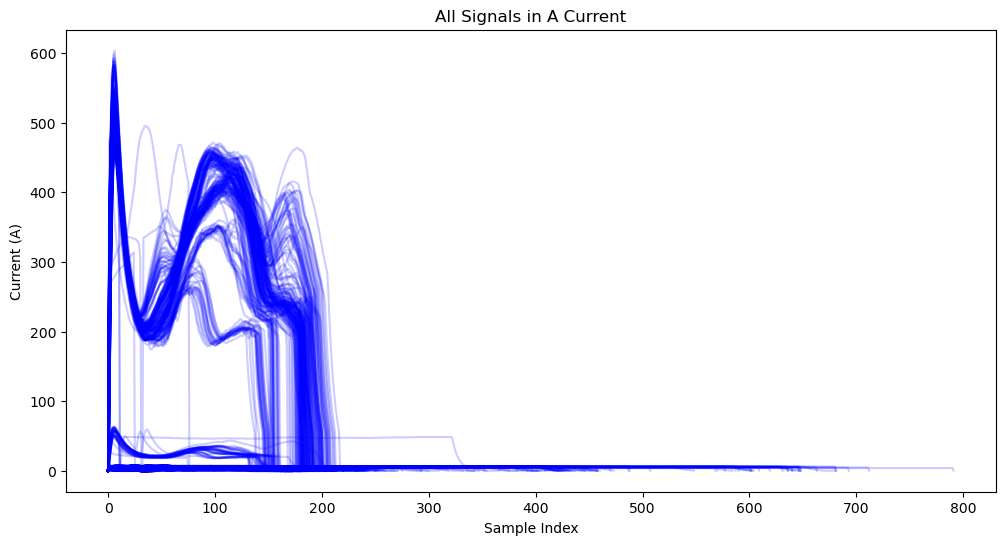

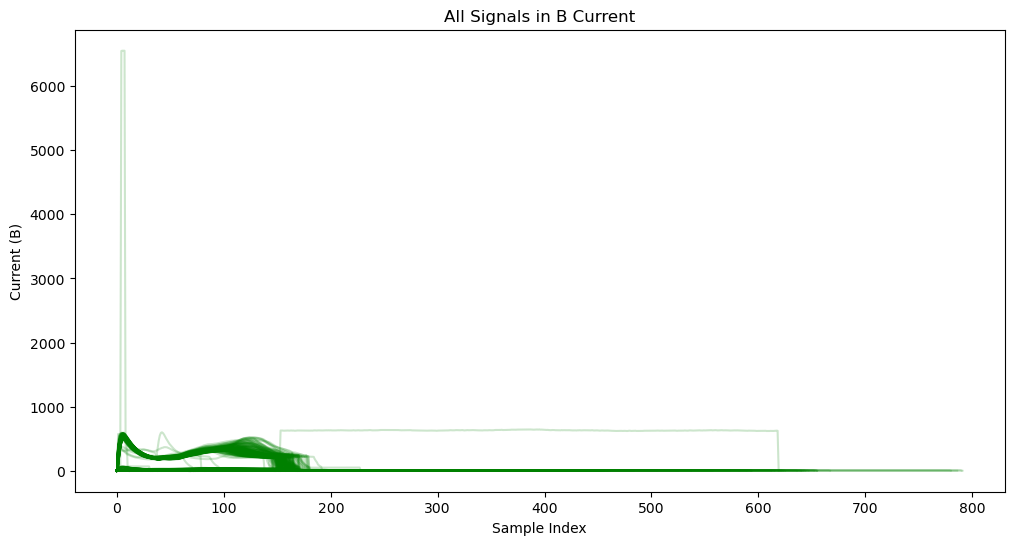

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ast

# Plot all signals in 'A Current'
plt.figure(figsize=(12, 6))
for signals in df['A Current']:
    if isinstance(signals, str):
        signals = ast.literal_eval(signals)
    values = np.array(signals, dtype=float)
    plt.plot(values, alpha=0.2, color='blue')
plt.title('All Signals in A Current')
plt.xlabel('Sample Index')
plt.ylabel('Current (A)')
plt.show()

# Plot all signals in 'B Current'
plt.figure(figsize=(12, 6))
for signals in df['B Current']:
    if isinstance(signals, str):
        signals = ast.literal_eval(signals)
    values = np.array(signals, dtype=float)
    plt.plot(values, alpha=0.2, color='green')
plt.title('All Signals in B Current')
plt.xlabel('Sample Index')
plt.ylabel('Current (B)')
plt.show()

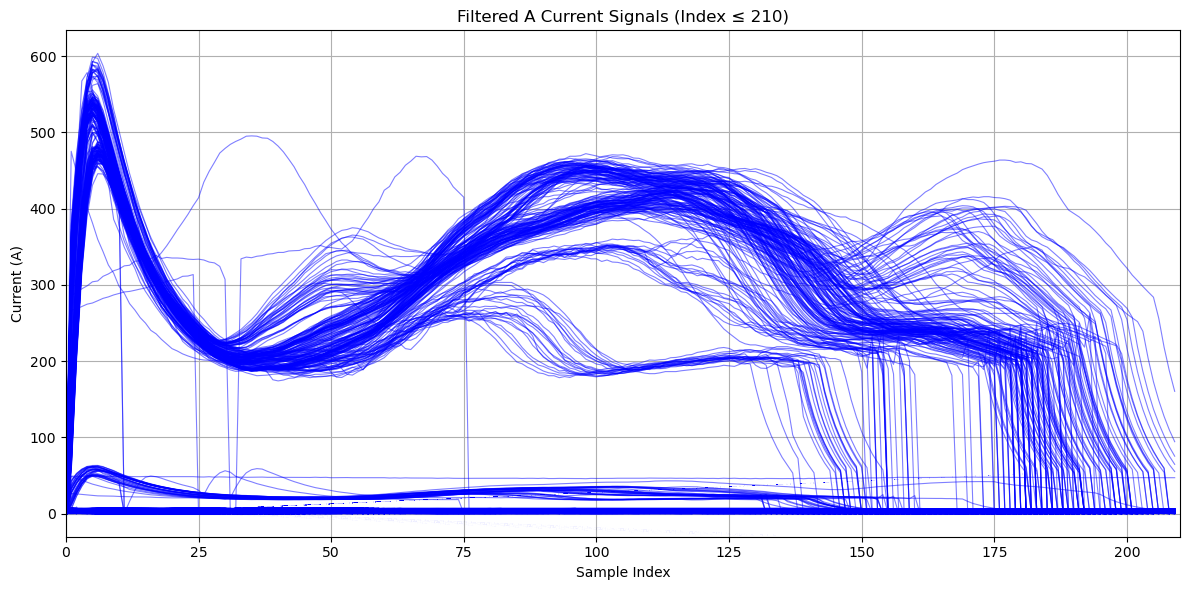

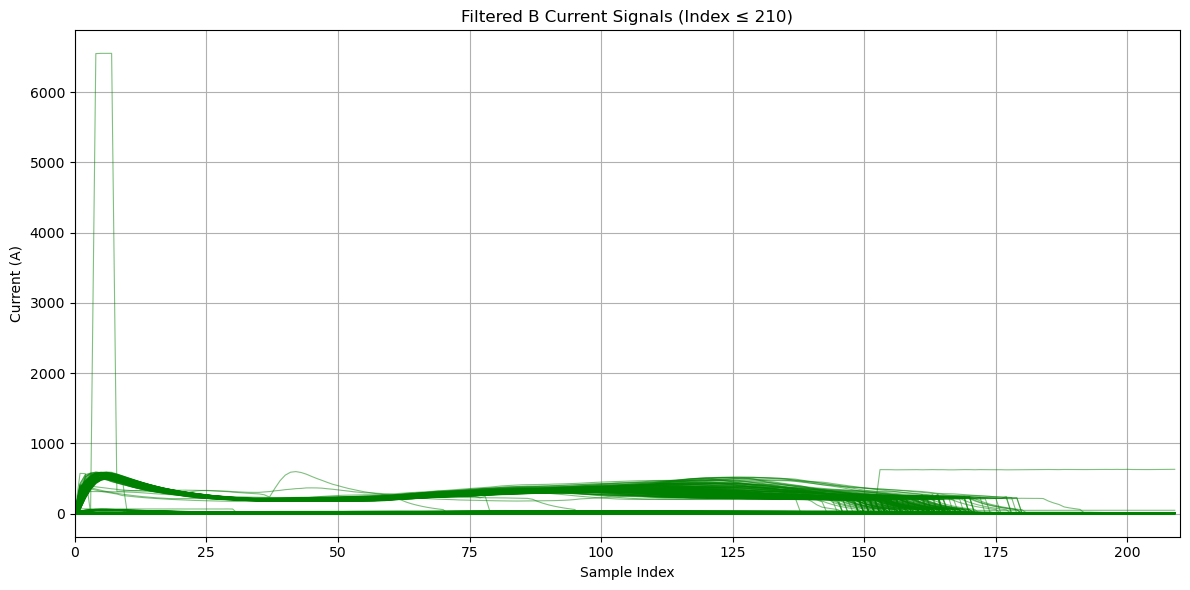

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ast

def plot_filtered_signals(df, current_column, color='blue', max_index=210, dead_threshold=0.5):
    """Plot filtered current signals with dead signal removal and index truncation."""
    plt.figure(figsize=(12, 6))
    
    for signals in df[current_column]:
        # Safely convert string to list if needed
        if isinstance(signals, str):
            signals = ast.literal_eval(signals)
        
        values = np.array(signals, dtype=float)
        
        # Filter 1: Remove dead signals (max current < threshold)
        if np.max(values) < dead_threshold:
            continue
            
        # Filter 2: Truncate at max_index
        values = values[:max_index]
        
        plt.plot(values, alpha=0.5, color=color, linewidth=0.8)
    
    plt.title(f'Filtered {current_column} Signals (Index ≤ {max_index})')
    plt.xlabel('Sample Index')
    plt.ylabel('Current (A)')
    plt.xlim(0, max_index)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot filtered signals
plot_filtered_signals(df, 'A Current', color='blue')
plot_filtered_signals(df, 'B Current', color='green')

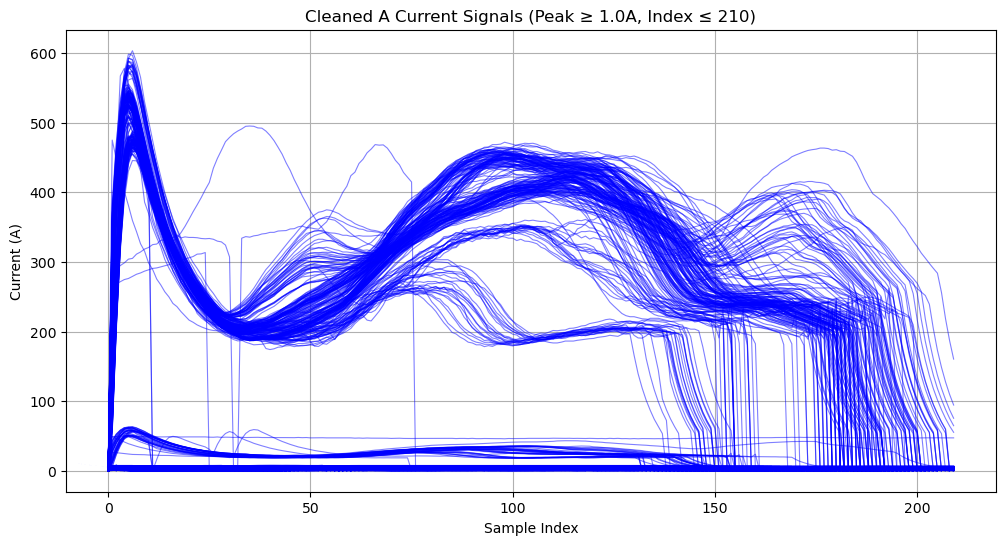

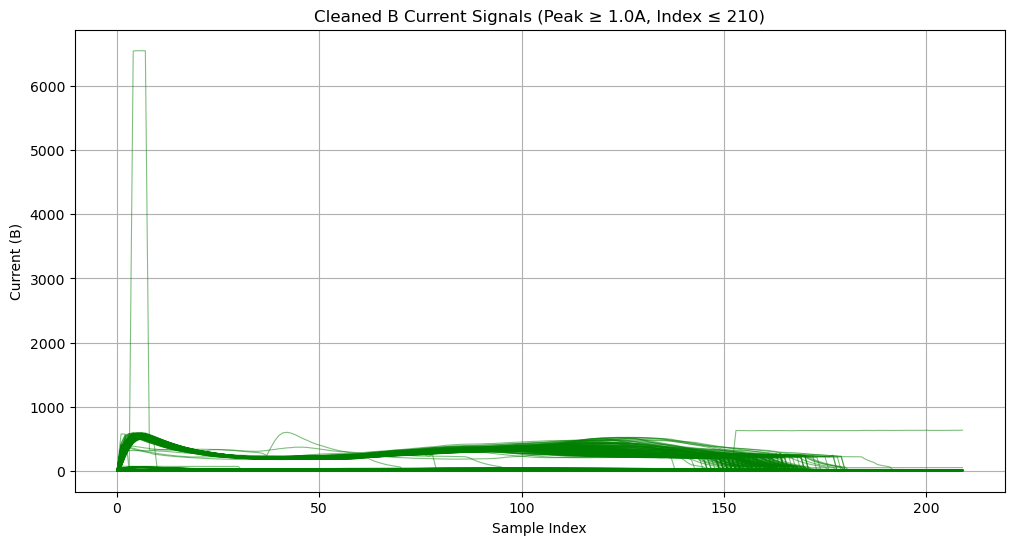

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

def remove_dead_signals(df, current_column, threshold=1.0):
    """Remove signals with peak current below threshold"""
    cleaned_data = []
    
    for index, row in df.iterrows():
        signals = row[current_column]
        if isinstance(signals, str):
            signals = ast.literal_eval(signals)
        
        peak_current = max(signals)
        if peak_current >= threshold:
            cleaned_data.append(row)
    
    return pd.DataFrame(cleaned_data)

# Parameters (adjust as needed)
PEAK_THRESHOLD = 1.0  # Minimum peak current to keep (A)
MAX_INDEX = 210

# Create cleaned datasets
df_clean_A = remove_dead_signals(df, 'A Current', threshold=PEAK_THRESHOLD)
df_clean_B = remove_dead_signals(df, 'B Current', threshold=PEAK_THRESHOLD)

# Plot cleaned A Current signals
plt.figure(figsize=(12, 6))
for signals in df_clean_A['A Current']:
    values = ast.literal_eval(signals) if isinstance(signals, str) else signals
    plt.plot(values[:MAX_INDEX], alpha=0.5, color='blue', linewidth=0.8)
plt.title(f'Cleaned A Current Signals (Peak ≥ {PEAK_THRESHOLD}A, Index ≤ {MAX_INDEX})')
plt.xlabel('Sample Index')
plt.ylabel('Current (A)')
plt.grid(True)
plt.show()

# Plot cleaned B Current signals
plt.figure(figsize=(12, 6))
for signals in df_clean_B['B Current']:
    values = ast.literal_eval(signals) if isinstance(signals, str) else signals
    plt.plot(values[:MAX_INDEX], alpha=0.5, color='green', linewidth=0.8)
plt.title(f'Cleaned B Current Signals (Peak ≥ {PEAK_THRESHOLD}A, Index ≤ {MAX_INDEX})')
plt.xlabel('Sample Index')
plt.ylabel('Current (B)')
plt.grid(True)
plt.show()

# Optional: Save cleaned datasets
df_clean_A.to_csv('cleaned_A_current_signals.csv', index=False)
# df_clean_B.to_csv('cleaned_B_current_signals.csv', index=False)

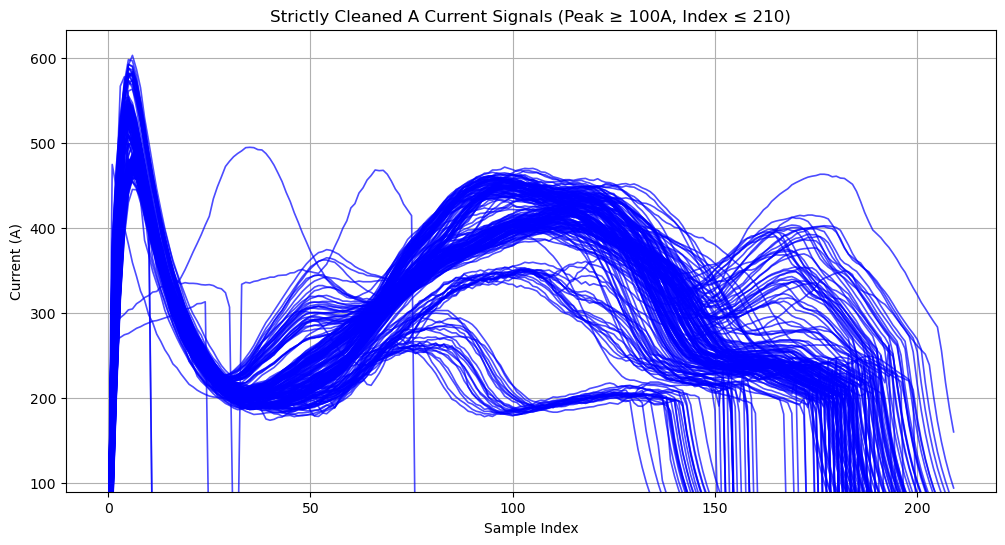

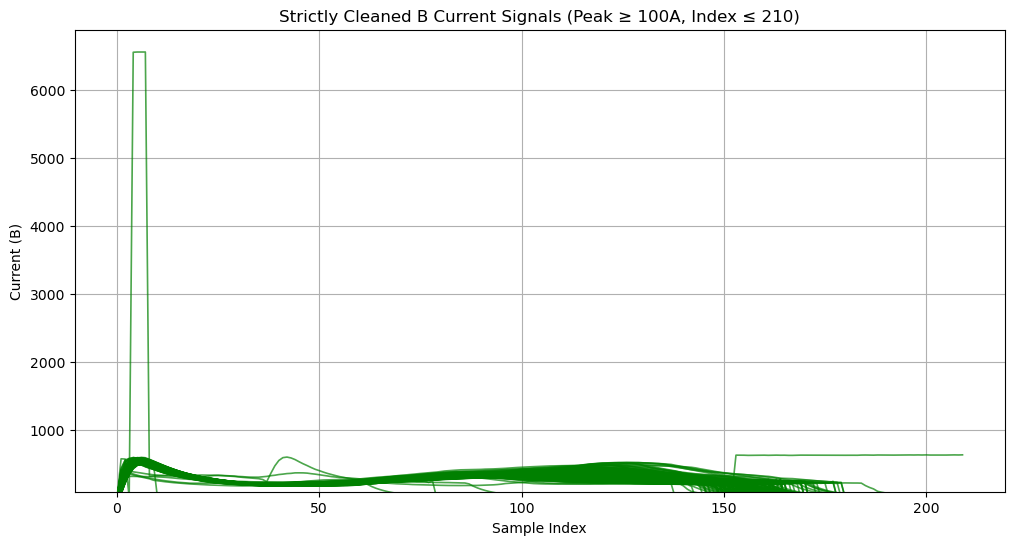

Original A Current signals: 11397
Strictly cleaned A Current signals: 207
Original B Current signals: 11397
Strictly cleaned B Current signals: 207


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

def remove_weak_signals(df, current_column, min_peak=100):
    """Remove signals with peak current below specified threshold"""
    cleaned_data = []
    
    for index, row in df.iterrows():
        signals = row[current_column]
        if isinstance(signals, str):
            signals = ast.literal_eval(signals)
        
        peak_current = max(signals)
        if peak_current >= min_peak:
            cleaned_data.append(row)
    
    return pd.DataFrame(cleaned_data)

# Parameters
MIN_PEAK = 100  # Minimum peak current to keep (A)
MAX_INDEX = 210  # Truncate signals at this index

# Create strictly cleaned datasets
df_strict_clean_A = remove_weak_signals(df, 'A Current', min_peak=MIN_PEAK)
df_strict_clean_B = remove_weak_signals(df, 'B Current', min_peak=MIN_PEAK)

# Plot cleaned A Current signals
plt.figure(figsize=(12, 6))
for signals in df_strict_clean_A['A Current']:
    values = ast.literal_eval(signals) if isinstance(signals, str) else signals
    plt.plot(values[:MAX_INDEX], alpha=0.7, color='blue', linewidth=1.2)
plt.title(f'Strictly Cleaned A Current Signals (Peak ≥ {MIN_PEAK}A, Index ≤ {MAX_INDEX})')
plt.xlabel('Sample Index')
plt.ylabel('Current (A)')
plt.ylim(MIN_PEAK*0.9, None)  # Focus on higher current range
plt.grid(True)
plt.show()

# Plot cleaned B Current signals
plt.figure(figsize=(12, 6))
for signals in df_strict_clean_B['B Current']:
    values = ast.literal_eval(signals) if isinstance(signals, str) else signals
    plt.plot(values[:MAX_INDEX], alpha=0.7, color='green', linewidth=1.2)
plt.title(f'Strictly Cleaned B Current Signals (Peak ≥ {MIN_PEAK}A, Index ≤ {MAX_INDEX})')
plt.xlabel('Sample Index')
plt.ylabel('Current (B)')
plt.ylim(MIN_PEAK*0.9, None)  # Focus on higher current range
plt.grid(True)
plt.show()

# Print cleaning results
print(f"Original A Current signals: {len(df)}")
print(f"Strictly cleaned A Current signals: {len(df_strict_clean_A)}")
print(f"Original B Current signals: {len(df)}")
print(f"Strictly cleaned B Current signals: {len(df_strict_clean_B)}")

# Optional: Save cleaned datasets
df_strict_clean_A.to_csv('strictly_cleaned_A_current.csv', index=False)
# df_strict_clean_B.to_csv('strictly_cleaned_B_current.csv', index=False)

In [15]:
data = pd.read_csv('strictly_cleaned_A_current.csv')
data.head()

,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
0,2025-06-02 12:33:07,ARNETHA,117/118,Reverse,"[0.0, 327.2, 423.6, 489.9, 524.6, 534.5, 524.6...","[0.0, 11544.0, 11520.0, 11035.5, 10468.5, 1006...","[0.0, 192.4, 331.0, 434.3, 490.7, 513.2, 515.1...","[0.0, 942.0, 1759.5, 2491.5, 3222.0, 3988.5, 4...",TWS,TWS,20,20
1,2025-06-02 12:34:01,ARNETHA,117/118,Normal,"[0.0, 254.8, 364.6, 435.8, 472.0, 481.2, 473.9...","[0.0, 1159.5, 2016.0, 2776.5, 3543.0, 4308.0, ...","[0.0, 345.1, 441.5, 510.9, 568.8, 549.0, 528.4...","[0.0, 10521.0, 10006.5, 9675.0, 9480.0, 9435.0...",TWS,TWS,20,20
2,2025-06-02 12:41:25,ARNETHA,117/118,Normal,"[0.0, 172.9, 303.2, 398.9, 454.1, 478.5, 480.8...","[0.0, 1273.5, 2103.0, 2857.5, 3628.5, 4393.5, ...","[0.0, 307.0, 414.5, 494.5, 547.4, 571.5, 575.3...","[0.0, 10354.5, 9880.5, 9600.0, 9492.0, 9492.0,...",TWS,TWS,20,20
3,2025-06-02 12:41:15,ARNETHA,117/118,Reverse,"[0.0, 307.0, 408.4, 480.4, 523.1, 537.5, 529.2...","[0.0, 10869.0, 10840.5, 10840.5, 10869.0, 1085...","[0.0, 65.5, 228.9, 360.0, 452.2, 499.4, 513.5,...","[0.0, 1399.5, 2719.5, 3846.0, 4806.0, 5634.0, ...",TWS,TWS,20,20
4,2025-06-02 15:20:30,ARNETHA,117/118,Normal,"[0.0, 72.7, 216.7, 332.9, 411.8, 454.9, 471.2,...","[0.0, 1599.0, 2359.5, 3085.5, 3834.0, 4588.5, ...","[0.0, 301.7, 406.1, 488.4, 541.0, 569.2, 575.3...","[0.0, 9240.0, 9144.0, 9114.0, 9195.0, 9337.5, ...",TWS,TWS,20,20


In [16]:
data.tail()

,Time,Site Name,Point Machine Name,Direction,A Current,A Voltage,B Current,B Voltage,Type of A,Type of B,Polling of A,Polling of B
202,2025-03-10 17:44:28,Dadhdevi,PT 101/102,Normal,"[0.0, 291.0, 411.4, 503.3, 561.9, 589.0, 584.0...","[0.0, 10920.0, 10287.0, 9732.0, 9303.0, 9046.5...","[0.0, 198.1, 323.4, 415.2, 468.2, 494.5, 496.4...","[0.0, 1051.5, 1873.5, 2599.5, 3307.5, 4039.5, ...",TWS,TWS,20,20
203,2025-03-10 18:39:50,Dadhdevi,PT 101/102,Reverse,"[0.0, 167.6, 309.7, 422.5, 491.4, 507.8, 503.6...","[0.0, 1582.5, 2268.0, 3010.5, 3793.5, 4600.5, ...","[0.0, 378.3, 484.2, 549.0, 578.7, 580.6, 562.7...","[0.0, 10075.5, 9618.0, 9394.5, 9337.5, 9406.5,...",TWS,TWS,20,20
204,2025-03-10 18:43:44,Dadhdevi,PT 101/102,Normal,"[0.0, 248.4, 376.4, 478.1, 549.4, 578.3, 584.4...","[0.0, 11137.5, 10515.0, 9892.5, 9457.5, 9126.0...","[0.0, 208.4, 340.2, 432.4, 485.3, 511.6, 509.7...","[0.0, 1125.0, 1930.5, 2640.0, 3325.5, 4023.0, ...",TWS,TWS,20,20
205,2025-03-11 08:30:50,Dadhdevi,PT 101/102,Reverse,"[0.0, 61.7, 232.7, 363.0, 457.9, 496.0, 500.2,...","[0.0, 1200.0, 2485.5, 3565.5, 4468.5, 5296.5, ...","[0.0, 333.7, 454.9, 537.5, 579.8, 587.8, 577.9...","[0.0, 8886.0, 9081.0, 9234.0, 9378.0, 9492.0, ...",TWS,TWS,20,20
206,2025-03-11 08:31:01,Dadhdevi,PT 101/102,Normal,"[0.0, 244.9, 374.9, 470.1, 539.1, 568.4, 574.5...","[0.0, 9097.5, 8469.0, 8109.0, 7857.0, 7812.0, ...","[0.0, 144.7, 293.3, 403.4, 474.7, 512.8, 512.0...","[0.0, 1068.0, 1731.0, 2353.5, 3000.0, 4245.0, ...",TWS,TWS,20,20


In [17]:
data['Point Machine Name'].nunique()

2

In [18]:
import pandas as pd
import numpy as np

# Read the CSV file
df1 = pd.read_csv('/Users/anamikasaroha/Energy7_Week1/week_10/NFR.csv')

# Filter rows where both Type of A and Type of B are TWS
filtered_df = df1[(df1['Type of A'] == 'TWS') & (df1['Type of B'] == 'TWS')]

# Remove rows with any null values
filtered_df = filtered_df.dropna()

# Function to check if all values in a string-represented array are 0.0
def is_all_zero_in_array(arr_str):
    try:
        values = [float(x) for x in arr_str.strip('"').split(',')]
        return all(v == 0.0 for v in values)
    except:
        return False

# Columns that contain array-like data
array_cols = ['A Current', 'A Voltage', 'B Current', 'B Voltage']

# Remove rows where all array values are 0.0 in all array columns
mask = filtered_df[array_cols].apply(lambda col: col.apply(is_all_zero_in_array)).all(axis=1)
filtered_df = filtered_df[~mask]

# Save the cleaned data to a new CSV file
filtered_df.to_csv('NFR_TWS.csv', index=False)

print(f"Original rows: {len(df1)}")
print(f"Filtered rows: {len(filtered_df)}")
print("Cleaned data saved to cleaned_data.csv")

Original rows: 125559
Filtered rows: 19913
Cleaned data saved to cleaned_data.csv


In [19]:
import pandas as pd
import ast

def clean_data(input_file, output_file):
    # Read CSV
    df = pd.read_csv(input_file)
    
    # Filter for TWS types only
    filtered_df = df[(df['Type of A'] == 'TWS') & (df['Type of B'] == 'TWS')].copy()
    
    # Drop rows with any NA/null values
    filtered_df = filtered_df.dropna()
    
    # Columns to check for zeros
    array_cols = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
    scalar_cols = ['Polling of A', 'Polling of B']  # Add other numeric columns if needed
    
    def is_all_zero(value):
        # Handle array-like strings
        if isinstance(value, str):
            try:
                # Safely evaluate string as list
                values = ast.literal_eval(value.strip('"'))
                return all(float(x) == 0.0 for x in values)
            except:
                return False
        # Handle regular numeric values
        return float(value) == 0.0
    
    # Check each row
    rows_to_keep = []
    for _, row in filtered_df.iterrows():
        # Check array columns
        array_all_zero = all(is_all_zero(row[col]) for col in array_cols)
        # Check scalar columns
        scalar_all_zero = all(float(row[col]) == 0.0 for col in scalar_cols)
        # Only keep rows that aren't all zeros
        if not (array_all_zero and scalar_all_zero):
            rows_to_keep.append(row)
    
    # Create new DataFrame
    cleaned_df = pd.DataFrame(rows_to_keep)
    
    # Save to new CSV
    cleaned_df.to_csv(output_file, index=False)
    
    print(f"Original rows: {len(df)}")
    print(f"After TWS filter: {len(filtered_df)}")
    print(f"After zero removal: {len(cleaned_df)}")
    print(f"Cleaned data saved to {output_file}")

# Usage
clean_data('/Users/anamikasaroha/Energy7_Week1/week_10/NFR.csv', 'NFR_TWS.csv')

Original rows: 125559
After TWS filter: 19913
After zero removal: 19913
Cleaned data saved to NFR_TWS.csv


In [20]:
import pandas as pd
import ast

def clean_data(input_file, output_file, strict=True):
    # Read CSV
    df = pd.read_csv(input_file)
    
    # Filter for TWS types only
    filtered_df = df[(df['Type of A'] == 'TWS') & (df['Type of B'] == 'TWS')].copy()
    
    # Drop rows with any NA/null values
    filtered_df = filtered_df.dropna()
    
    # Columns containing array data
    array_cols = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
    
    def is_all_zero_array(arr_str):
        """Check if an array string contains only zeros"""
        if not isinstance(arr_str, str):
            return False
        try:
            # Remove quotes and split
            cleaned = arr_str.strip('"')
            # Handle empty strings
            if not cleaned:
                return True
            # Convert to list of floats
            values = [float(x) for x in cleaned.split(',')]
            return all(v == 0.0 for v in values)
        except:
            return False
    
    # Apply the check to all array columns
    if strict:
        # Strict mode: Remove if ANY array column is all zeros
        mask = filtered_df[array_cols].applymap(is_all_zero_array).any(axis=1)
    else:
        # Normal mode: Remove only if ALL array columns are all zeros
        mask = filtered_df[array_cols].applymap(is_all_zero_array).all(axis=1)
    
    # Invert mask to keep rows that don't match our criteria
    cleaned_df = filtered_df[~mask]
    
    # Additional check for scalar zero values in polling columns
    polling_cols = ['Polling of A', 'Polling of B']
    zero_polling_mask = (cleaned_df[polling_cols] == 0).all(axis=1)
    cleaned_df = cleaned_df[~zero_polling_mask]
    
    # Save to new CSV
    cleaned_df.to_csv(output_file, index=False)
    
    print(f"Original rows: {len(df)}")
    print(f"After TWS filter: {len(filtered_df)}")
    print(f"After zero removal: {len(cleaned_df)}")
    print(f"Cleaned data saved to {output_file}")

# Usage - set strict=False if you only want to remove rows where ALL arrays are zero
clean_data('/Users/anamikasaroha/Energy7_Week1/week_10/NFR.csv', 'NFR_TWS.csv', strict=False)

/var/folders/6k/z_5jgpzx3gv7nz188p4vycxr0000gn/T/ipykernel_68164/1702658909.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = filtered_df[array_cols].applymap(is_all_zero_array).all(axis=1)


Original rows: 125559
After TWS filter: 19913
After zero removal: 19913
Cleaned data saved to NFR_TWS.csv


In [21]:
import pandas as pd

# Load CSV (adjust the path accordingly)
data = pd.read_csv("/Users/anamikasaroha/Energy7_Week1/week_10/NFR_TWS.csv")

# Define the columns that contain array-like strings
array_columns = ["A Current", "A Voltage", "B Current", "B Voltage"]

# Function to check if a string array contains only 0.0 values
def is_all_zeros(array_str):
    try:
        numbers = [float(x.strip()) for x in array_str.split(",")]
        return all(num == 0.0 for num in numbers)
    except:
        return False

# Keep only rows where none of the array columns are entirely zeros
filtered_data = data[~data[array_columns].applymap(is_all_zeros).any(axis=1)]

# Save or preview the result
filtered_data.to_csv("filtered_NFR.csv", index=False)
print(filtered_data)


/var/folders/6k/z_5jgpzx3gv7nz188p4vycxr0000gn/T/ipykernel_68164/3550323480.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  filtered_data = data[~data[array_columns].applymap(is_all_zeros).any(axis=1)]


                      Time Site Name Point Machine Name Direction  \
0      2025-06-12 10:58:23   NALBARI         PT-101/102   Reverse   
1      2025-06-12 11:03:48   NALBARI         PT-101/102    Normal   
2      2024-12-12 10:44:54   NALBARI         PT-101/102   Reverse   
3      2024-12-12 10:52:09   NALBARI         PT-101/102    Normal   
4      2024-12-12 11:19:11   NALBARI         PT-101/102   Reverse   
...                    ...       ...                ...       ...   
19908  2025-06-11 20:49:34  Sorupeta         PT 105/106    Normal   
19909  2025-06-11 06:07:21  Sorupeta         PT 105/106    Normal   
19910  2025-06-11 07:34:27  Sorupeta         PT 105/106   Reverse   
19911  2025-06-11 15:40:29  Sorupeta         PT 105/106   Reverse   
19912  2025-06-11 19:35:19  Sorupeta         PT 105/106    Normal   

                                               A Current  \
0      0.8,4.0,3.5,2.8,2.3,2.0,1.8,1.8,1.9,2.0,2.1,2....   
1      0.7,3.9,3.3,2.7,2.3,2.0,1.8,1.7,1.6,1.6,1.6,